In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [53]:
!pip install -U git+https://github.com/qubvel/classification_models.git

  Cloning https://github.com/qubvel/classification_models.git to /tmp/pip-req-build-9nk8p815
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/classification_models.git /tmp/pip-req-build-9nk8p815
  Resolved https://github.com/qubvel/classification_models.git to commit a0f006e05485a34ccf871c421279864b0ccd220b
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done


In [54]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from classification_models.tfkeras import Classifiers
from tensorflow.keras.layers import (Input, Conv2D, GlobalAveragePooling2D,
                                     Dense, Multiply, Add, Concatenate, Reshape,
                                     Activation, Lambda)
from tensorflow.keras.models import Model


In [55]:
dataset_path = '/kaggle/input/rice-disease-dataset/Rice_Leaf_AUG'
img_size = (128, 128)
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE


In [56]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int',
    shuffle=True,  # shuffle data before splitting
    validation_split=0.2,  # Split into training and validation sets
    subset="training",  # Set this to "training" for the training subset
    seed=123
)


Found 3829 files belonging to 6 classes.
Using 3064 files for training.


In [60]:
ResNet34, preprocess_input = Classifiers.get('resnet34')
preprocess_layer = tf.keras.layers.Lambda(lambda x: preprocess_input(x))

In [61]:
def Cosin_similarity(tensors):
    a, b = tensors
    dot_product = tf.reduce_sum(a * b, axis=-1, keepdims=True)
    norm_a = tf.norm(a, axis=-1, keepdims=True)
    norm_b = tf.norm(b, axis=-1, keepdims=True)
    return dot_product / (norm_a * norm_b + tf.keras.backend.epsilon())

In [62]:
def Bund(inputs):
    alpha_1, alpha_2 = inputs
    total = alpha_1 + alpha_2 + tf.keras.backend.epsilon()
    alpha_l = alpha_1 / total
    alpha_g = alpha_2 / total
    return alpha_l, alpha_g

In [63]:
def eca_module(input_tensor, gamma=2):
    channels = input_tensor.shape[-1]
    squeeze = GlobalAveragePooling2D()(input_tensor)
    excitation = Dense(units=channels // gamma)(squeeze)
    excitation = Activation('relu')(excitation)
    excitation = Dense(units=channels)(excitation)
    excitation = Activation('sigmoid')(excitation)
    excitation = Reshape((1, 1, channels))(excitation)
    scale = Multiply()([input_tensor, excitation])
    output = Add()([scale, input_tensor])
    return output

In [64]:
def res_csa_module(input_tensor, reduction_ratio=16):
    channels = input_tensor.shape[-1]
    conv1 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(input_tensor)
    conv2 = Conv2D(filters=channels // reduction_ratio, kernel_size=(1,1), padding='same', activation='relu')(conv1)
    conv3 = Conv2D(filters=channels, kernel_size=(1,1), padding='same', activation='relu')(conv2)
    attention_map = Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(conv3)
    attention = Multiply()([attention_map, input_tensor])
    output = Add()([attention, input_tensor])
    return output

In [65]:
def build_model(input_shape, num_classes):
    input_tensor = Input(shape=input_shape)
    x = preprocess_layer(input_tensor)
    backbone_output = ResNet34(input_shape=input_shape, weights='imagenet', include_top=False)(x)
    eca_out = eca_module(backbone_output)
    res_csa_out = res_csa_module(backbone_output)
    x = Add()([backbone_output, eca_out, res_csa_out])
    x_l = GlobalAveragePooling2D()(eca_out)
    x_g = GlobalAveragePooling2D()(res_csa_out)
    x_c = GlobalAveragePooling2D()(x)
    x_l = Dense(384, activation='relu')(x_l)
    x_g = Dense(384, activation='relu')(x_g)
    x_c = Dense(384, activation='relu')(x_c)
    share_1 = Dense(768, activation='relu')
    share_2 = Dense(768, activation='relu')
    x_l = share_1(x_l)
    x_g = share_1(x_g)
    x_c = share_1(x_c)
    x_l = share_2(x_l)
    x_g = share_2(x_g)
    x_c = share_2(x_c)
    x_l = Dense(num_classes, activation='softmax')(x_l)
    x_g = Dense(num_classes, activation='softmax')(x_g)
    x_c = Dense(num_classes, activation='softmax')(x_c)
    alpha_1 = Lambda(Cosin_similarity)([x_l, x_c])
    alpha_2 = Lambda(Cosin_similarity)([x_g, x_c])
    alpha_l, alpha_g = Lambda(Bund)([alpha_1, alpha_2])
    out_l = Multiply()([alpha_l, x_l])
    out_g = Multiply()([alpha_g, x_g])
    out = Concatenate()([out_l, out_g])
    out = Dense(64, activation='relu')(out)
    out = Dense(num_classes, activation='softmax')(out)
    model = Model(inputs=input_tensor, outputs=out)
    return model

In [66]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [67]:
model = build_model(input_shape=img_size + (3,), num_classes=len(full_ds.class_names))
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_14 (Lambda)        │ (None, 128, 128, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_8 (Functional) │ (None, 4, 4, 512)      │     21,302,473 │ lambda_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 512)            │              0 │ functional_8[0][0]     │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_48 (Dense)          │ (None, 256)            │        131,328 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_8 (Activation) │ (None, 256)            │              0 │ dense_48[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 4, 4, 32)       │         16,416 │ functional_8[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_49 (Dense)          │ (None, 512)            │        131,584 │ activation_8[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 4, 4, 32)       │          1,056 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_9 (Activation) │ (None, 512)            │              0 │ dense_49[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 4, 4, 512)      │         16,896 │ conv2d_17[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_4 (Reshape)       │ (None, 1, 1, 512)      │              0 │ activation_9[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 4, 4, 1)        │            513 │ conv2d_18[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_16 (Multiply)    │ (None, 4, 4, 512)      │              0 │ functional_8[0][0],    │
│                           │                        │                │ reshape_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_17 (Multiply)    │ (None, 4, 4, 512)      │              0 │ conv2d_19[0][0],       │
│                           │                        │                │ functional_8[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_92 (Add)              │ (None, 4, 4, 512)      │              0 │ multiply_16[0][0],     │
│                           │                        │                │ functional_8[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_93 (Add)              │ (None, 4, 4, 512)      │              0 │ multiply_17[0][0],     │
│                      

 Total params: 23,092,578 (88.09 MB)

 Trainable params: 23,077,212 (88.03 MB)

 Non-trainable params: 15,366 (60.02 KB)

In [68]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 298ms/step - accuracy: 0.2930 - loss: 1.7365 - val_accuracy: 0.3869 - val_loss: 1.6945
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.4883 - loss: 1.6228 - val_accuracy: 0.4497 - val_loss: 1.6170
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.5170 - loss: 1.5532 - val_accuracy: 0.5216 - val_loss: 1.5465
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.6166 - loss: 1.4890 - val_accuracy: 0.6052 - val_loss: 1.4835
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.6797 - loss: 1.4149 - val_accuracy: 0.5974 - val_loss: 1.4363
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.6973 - loss: 1.3522 - val_accuracy: 0.5712 - val_loss: 1.4470
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.6908 - loss: 1.3028 - val_accuracy: 0.5895 - val_loss: 1.3962
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.6992 - loss: 1.2384 - 

In [69]:
test_loss, test_accuracy = model.evaluate(test_ds)

120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.9782 - loss: 0.1324


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━

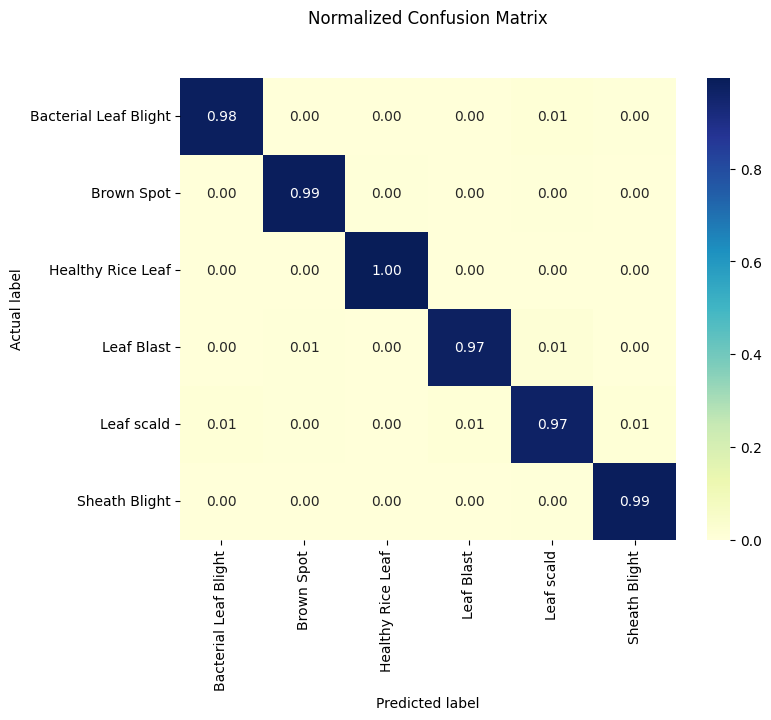

In [70]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Generate predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=-1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Define your class names (make sure this matches your dataset)
target_names = full_ds.class_names  # ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(cm), annot=True, fmt='.2f', cmap="YlGnBu",
            xticklabels=target_names, yticklabels=target_names)

plt.title('Normalized Confusion Matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


In [71]:
class_report = classification_report(y_true, y_pred, target_names=full_ds.class_names)
print("\nClassification Report:\n", class_report)


Classification Report:
                        precision    recall  f1-score   support

Bacterial Leaf Blight       0.98      0.98      0.98       636
           Brown Spot       0.99      0.99      0.99       646
    Healthy Rice Leaf       0.99      1.00      0.99       653
           Leaf Blast       0.98      0.97      0.98       634
           Leaf scald       0.97      0.97      0.97       628
        Sheath Blight       0.98      0.99      0.98       632

             accuracy                           0.98      3829
            macro avg       0.98      0.98      0.98      3829
         weighted avg       0.98      0.98      0.98      3829



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

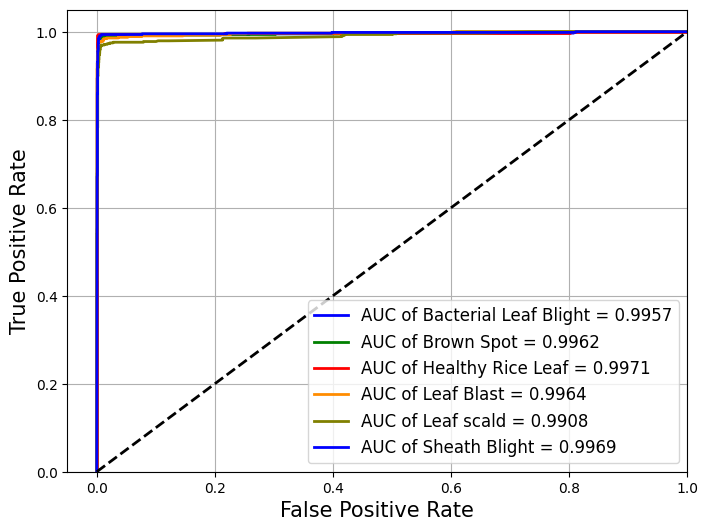

In [73]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

# First get the true labels and predicted probabilities
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)  # we need raw probabilities, not hard predictions!

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert y_true into one-hot encoding
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)

# Initialize dicts
fpr = dict()
tpr = dict()
roc_auc = dict()
lw = 2

# Compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting
colors = cycle(['blue', 'green', 'red', 'darkorange', 'olive'])  # use any colors you like
plt.figure(figsize=(8, 6))

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='AUC of {0} = {1:0.4f}'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
# plt.title('Receiver operating characteristic for multi-class data')
plt.legend(loc="lower right", fontsize=12)
plt.grid()
plt.show()
